### Q-Learning in a discrete search game (grid-world)

Prepared by: [Tirtharaj Dash](https://tirtharajdash.github.io)

#### **Markov Decision Process (MDP)**:

Reinforcement learning problems are formally modelled as MDPs. An MDP is defined by the tuple $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$:

| Symbol | Meaning |
|--------|---------|
| $\mathcal{S}$ | finite state space |
| $\mathcal{A}$ | finite action space |
| $P(s' \mid s, a)$ | transition probability: probability of reaching $s'$ from $s$ under action $a$ |
| $R(s, a, s')$ | reward received after transitioning from $s$ to $s'$ via $a$ |
| $\gamma \in [0, 1)$ | discount factor |

The **Markov property** requires:  
$$P(s_{t+1} \mid s_t, a_t, s_{t-1}, a_{t-1}, \ldots) = P(s_{t+1} \mid s_t, a_t)$$


#### What is a policy and what are value functions?

A **policy** $\pi: \mathcal{S} \to \mathcal{A}$ (deterministic) or $\pi(a \mid s)$ (stochastic) maps states to actions.

The **state-value function** under $\pi$:
$$V^\pi(s) = \mathbb{E}_\pi\left[\sum_{t=0}^{\infty} \gamma^t R_{t+1} \,\Big|\, S_0 = s\right]$$

The **action-value (Q) function** under $\pi$:
$$Q^\pi(s, a) = \mathbb{E}_\pi\left[\sum_{t=0}^{\infty} \gamma^t R_{t+1} \,\Big|\, S_0 = s, A_0 = a\right]$$

$Q^\pi(s, a)$ is the expected cumulative discounted return when starting in state $s$, taking action $a$, and thereafter following $\pi$.


#### Bellman optimality equations

The optimal Q-function $Q^*(s, a)$ satisfies:

$$Q^*(s, a) = \mathbb{E}_{s'}\left[R(s, a, s') + \gamma \max_{a'} Q^*(s', a')\right]$$

The optimal policy is then recovered greedily:
$$\pi^*(s) = \arg\max_{a \in \mathcal{A}}\, Q^*(s, a)$$

#### Q-Learning

Q-learning (Watkins, 1989) is a **model-free, off-policy** temporal-difference (TD) method that directly learns $Q^*$ without knowing $P$ or $R$.

**Update rule** (after observing transition $(s_t, a_t, r_t, s_{t+1})$):

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha\left[\underbrace{r_t + \gamma \max_{a'} Q(s_{t+1}, a')}_{\text{TD target}} - Q(s_t, a_t)\right]$$

where $\alpha \in (0, 1]$ is the learning rate. The bracketed term is the **TD error** $\delta_t$.

**Off-policy** means the update uses $\max_{a'}$ (greedy over $Q$) regardless of the action actually taken — the behaviour policy (used for exploration) and the target policy (greedy) are different.

**Convergence guarantee**: Q-learning converges to $Q^*$ with probability 1 provided every $(s, a)$ pair is visited infinitely often and $\sum_t \alpha_t = \infty$, $\sum_t \alpha_t^2 < \infty$ (Watkins & Dayan, 1992).

#### Exploration: $\varepsilon$-greedy policy

$$a_t = \begin{cases} \text{random} \in \mathcal{A} & \text{with probability } \varepsilon \\ \arg\max_{a} Q(s_t, a) & \text{with probability } 1 - \varepsilon \end{cases}$$

Typically $\varepsilon$ is annealed from 1.0 to a small floor (e.g., 0.01) over training.

#### Algorithm

```
Initialise Q(s, a) = 0 for all s, a
for each episode:
    s <- initial state
    while s is not terminal:
        a <- epsilon-greedy(Q, s)
        r, s' <- env.step(a)
        Q(s, a) <- Q(s, a) + alpha * [r + gamma * max_a' Q(s', a') - Q(s, a)]
        s <- s'
```

**References**  
- Watkins, C. J. C. H. (1989). *Learning from Delayed Rewards*. PhD thesis, University of Cambridge.  
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292.  
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. [http://incompleteideas.net/book/the-book.html](http://incompleteideas.net/book/the-book.html) (You can lool at chapter 6 that covers TD learning and Q-learning.)

#### Grid-world environment: Treasure Hunt

We will now implement a custom discrete grid game:

- **Grid**: $N \times N$ cells, each cell is a state $s = (r, c)$
- **Agent** starts at the top-left corner $(0, 0)$
- **Goal** (treasure) is at $(N-1, N-1)$; reaching it gives reward $+10$ and ends the episode
- **Traps**: selected cells give reward $-5$ and end the episode
- **Walls**: selected cells are impassable; the agent stays in its current cell (reward $-1$)
- **Step cost**: $-1$ per step to encourage short paths
- **Actions**: $\{\text{up}, \text{down}, \text{left}, \text{right}\}$

The state space has $N^2$ states and the action space has $|\mathcal{A}| = 4$ actions, so the Q-table is $N^2 \times 4$.

#### Relevant concept: TD learning

The agent navigates a 6×6 grid from start (0,0) to goal (5,5),
collecting rewards along the way. We use this to ground three ideas.

Here our core problem is this: estimate "how good is this cell?"

Suppose the agent is at cell (2,3) and wants to know:
*"If I stay here and play optimally, how much total reward will I collect?"*
That is $V(2,3)$ — the state-value. To learn it, it has three options.

**Option 1 — Monte Carlo**

The agent starts at (0,0), wanders the grid following some policy,
and eventually reaches the goal (or falls into a trap). Only then does
it look back at the full sequence of rewards and update every cell it visited.

$$V(s) \leftarrow V(s) + \alpha \left[G_t - V(s)\right]$$

where $G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \cdots$
is the actual discounted return from that episode.

*In GridWorld*: if the path was (0,0) → (1,0) → (2,0) → ... → (5,5),
the agent waits until it hits the goal, then updates every cell on the path.
If it falls into a trap at (4,4), it still waits for the episode to end
before learning anything. No update happens mid-episode.

*Problem*: on a large grid with many traps, episodes can be long or
fail early. Waiting for the episode to finish is wasteful.

**Option 2 — TD(0): learn at every step**

Instead of waiting, the agent updates $V(s)$ after *every single step*,
using the immediate reward plus its current estimate of the next cell:

$$V(s_t) \leftarrow V(s_t) + \alpha \left[r_{t+1} + \gamma V(s_{t+1}) - V(s_t)\right]$$

The term $r_{t+1} + \gamma V(s_{t+1})$ is the **TD target** —
a one-step lookahead that substitutes the true future return
with a bootstrapped estimate.

*In GridWorld*: the agent moves from (2,3) to (2,4), receives reward $-1$,
and immediately updates:

$$V(2,3) \leftarrow V(2,3) + \alpha \left[-1 + \gamma \, V(2,4) - V(2,3)\right]$$

No need to wait for the episode to end. The agent learns online,
cell by cell, as it walks.

*Limitation of TD(0)*: it learns $V(s)$ — how good a *state* is.
But to decide whether to go up, down, left, or right from (2,3),
we need to know how good each *action* is. That requires $Q(s, a)$.

**Option 3 — Q-Learning: TD applied to action-values**

Q-learning replaces $V(s)$ with $Q(s, a)$ — the expected return
for taking action $a$ in state $s$ and then acting optimally.
The update after observing $(s_t, a_t, r_{t+1}, s_{t+1})$ is:

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\right]$$

The $\max_{a'}$ replaces $V(s_{t+1})$ — because the best value of
the next state is exactly the return from taking the best action there.

*In GridWorld*: the agent is at (2,3) and moves right to (2,4),
receiving reward $-1$. It updates:

$$Q((2,3),\, \text{right}) \leftarrow Q((2,3),\, \text{right})
+ \alpha \left[-1 + \gamma \max_{a'} Q((2,4),\, a') - Q((2,3),\, \text{right})\right]$$

After enough episodes, $Q(s, a)$ converges to $Q^*(s, a)$,
and the greedy policy $\pi^*(s) = \arg\max_a Q^*(s,a)$ gives
the arrows shown in Section 10.


In **summary**:

| Method | Updates when? | Learns | Needs full episode? |
|---|---|---|---|
| Monte Carlo | End of episode | $V(s)$ or $Q(s,a)$ | Yes |
| TD(0) | Every step | $V(s)$ | No |
| Q-learning | Every step | $Q(s,a)$ | No |

Q-learning is TD(0) applied to action-values, with a greedy
bootstrap target — giving both the efficiency of TD and the
ability to directly recover an optimal policy.

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import random

In [50]:
class GridWorld:
    """
    N x N grid with a start, a goal, trap cells, and wall cells.

    Cell types stored in self.grid:
        0 -> free
        1 -> wall
        2 -> trap
        3 -> goal

    Actions: 0=up, 1=down, 2=left, 3=right
    """

    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    ACTION_NAMES = {0: 'up', 1: 'down', 2: 'left', 3: 'right'}

    def __init__(self, N=6, walls=None, traps=None, seed=42):
        self.N = N
        self.grid = np.zeros((N, N), dtype=int)
        self.start = (0, 0)
        self.goal = (N - 1, N - 1)
        self.grid[self.goal] = 3

        walls = walls or []
        traps = traps or []
        for w in walls:
            self.grid[w] = 1
        for t in traps:
            self.grid[t] = 2

        self.n_states = N * N
        self.n_actions = 4
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self._encode(self.state)

    def _encode(self, pos):
        return pos[0] * self.N + pos[1]

    def _decode(self, idx):
        return (idx // self.N, idx % self.N)

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.state
        nr, nc = r + dr, c + dc

        # boundary or wall: stay in place
        if not (0 <= nr < self.N and 0 <= nc < self.N) or self.grid[nr, nc] == 1:
            return self._encode(self.state), -1.0, False

        self.state = (nr, nc)
        cell = self.grid[nr, nc]

        if cell == 3:  # goal
            return self._encode(self.state), 10.0, True
        elif cell == 2:  # trap
            return self._encode(self.state), -5.0, True
        else:
            return self._encode(self.state), -1.0, False

    def render(self, agent_pos=None, ax=None):
        show = ax is None
        if ax is None:
            fig, ax = plt.subplots(figsize=(5, 5))

        cmap = ListedColormap(['white', '#555555', '#e74c3c', '#2ecc71'])
        ax.imshow(self.grid, cmap=cmap, vmin=0, vmax=3)

        # grid lines
        for x in range(self.N + 1):
            ax.axhline(x - 0.5, color='black', linewidth=0.5)
            ax.axvline(x - 0.5, color='black', linewidth=0.5)

        if agent_pos is not None:
            r, c = agent_pos
            ax.text(c, r, 'A', ha='center', va='center', fontsize=14, fontweight='bold', color='navy')

        ax.text(self.goal[1], self.goal[0], 'G', ha='center', va='center', fontsize=12, color='black')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title('GridWorld')

        patches = [
            mpatches.Patch(color='white', label='Free'),
            mpatches.Patch(color='#555555', label='Wall'),
            mpatches.Patch(color='#e74c3c', label='Trap'),
            mpatches.Patch(color='#2ecc71', label='Goal'),
        ]
        ax.legend(handles=patches, loc='upper right', fontsize=7, bbox_to_anchor=(1.35, 1))

        if show:
            plt.tight_layout()
            plt.show()

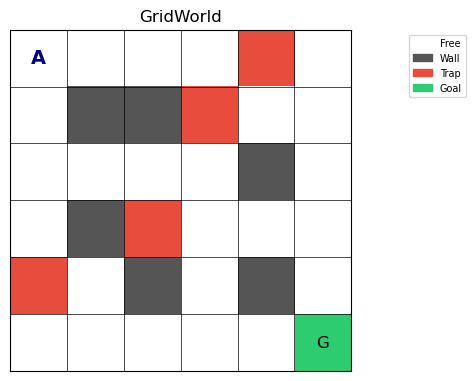

In [51]:
# Define the grid layout
WALLS = [(1, 1), (1, 2), (2, 4), (3, 1), (4, 2), (4,4)]
TRAPS = [(0,4), (1, 3), (3,2), (4,0)]

env = GridWorld(N=6, walls=WALLS, traps=TRAPS)
env.render(agent_pos=env.start)

#### Q-Learning Agent

**Exploration vs Exploitation: the $\varepsilon$-Greedy Policy**

At any point during training, the agent faces a dilemma:

- **Exploit**: pick the action with the highest current Q-value (greedy)
- **Explore**: pick a random action to discover potentially better paths

If the agent always exploits, it gets stuck with whatever it learned
early on — which may be suboptimal, because the Q-table is nearly all
zeros at the start. If it always explores, it never uses what it has
learned. $\varepsilon$-greedy is the simplest resolution:

$$a_t = \begin{cases} \text{random action} & \text{with probability } \varepsilon \\ \arg\max_{a}\, Q(s_t, a) & \text{with probability } 1 - \varepsilon \end{cases}$$

In the code below, $\varepsilon$ starts at 1.0 (pure random) and
decays multiplicatively after each episode:

$$\varepsilon \leftarrow \max(\varepsilon_{\min},\; \varepsilon \times \varepsilon_{\text{decay}})$$

with $\varepsilon_{\text{decay}} = 0.995$ and $\varepsilon_{\min} = 0.01$.

*In GridWorld*: early on, the agent tries all sorts of paths —
walks into walls, falls into traps — accumulating experience across
the grid. As $\varepsilon$ decays, it increasingly trusts the Q-table
and follows the greedy path. By episode $Max_ep$ (say, 200), $\varepsilon \approx 0.01$,
so the agent is almost fully exploiting. The third plot in the learning
curves (Section 8) shows exactly this decay.

In [52]:
class QLearningAgent:
    """
    Tabular Q-learning with epsilon-greedy exploration.

    Q-table shape: (n_states, n_actions)
    Update: Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
    """

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99,
                 eps_start=1.0, eps_end=0.01, eps_decay=0.995):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.Q = np.zeros((n_states, n_actions))

    def select_action(self, state):
        if random.random() < self.eps:
            return random.randint(0, self.n_actions - 1)
        return int(np.argmax(self.Q[state]))

    def update(self, s, a, r, s_next, done):
        td_target = r + (0.0 if done else self.gamma * np.max(self.Q[s_next]))
        td_error = td_target - self.Q[s, a]
        self.Q[s, a] += self.alpha * td_error

    def decay_epsilon(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)

#### Training

Training is the process of running the agent through many episodes
of the GridWorld game so that the Q-table fills in with meaningful values.

One episode proceeds as follows:
```
reset agent to (0,0)
repeat:
    pick action (epsilon-greedy)
    take step → get (s', r, done)
    update Q(s, a) via TD error
    s <- s'
until goal/trap reached or max_steps hit
```

Training = running this loop for $Max_ep$ (e.g. 200) episodes.

- **Episode 1**: Q-table is all zeros, agent wanders randomly.
- **Episode 200**: Q-table has converged to $Q^*(s,a)$ for every
  reachable cell, because each $(s,a)$ pair has been visited many
  times and TD updates have propagated reward signals backward
  through the grid.

At the end of training, the Q-table is fixed and ready to be queried.
The greedy rollout and Q-table visualisation in the later cells use
this converged Q-table — they do not update it further.

Note: "training" here does not mean training a neural network.
It is simply the iterative process of filling a $36 \times 4$ table
(36 states, 4 actions) with accurate Q-values through repeated
interaction with the environment.

In [53]:
def train(env, agent, n_episodes=200, max_steps=200):
    rewards_per_episode = []
    steps_per_episode = []
    eps_history = []

    for ep in range(n_episodes):
        s = env.reset()
        total_reward = 0

        for step in range(max_steps):
            a = agent.select_action(s)
            s_next, r, done = env.step(a)
            agent.update(s, a, r, s_next, done)
            s = s_next
            total_reward += r
            if done:
                break

        agent.decay_epsilon()
        rewards_per_episode.append(total_reward)
        steps_per_episode.append(step + 1)
        eps_history.append(agent.eps)

    return rewards_per_episode, steps_per_episode, eps_history


np.random.seed(42)
random.seed(42)

env = GridWorld(N=6, walls=WALLS, traps=TRAPS)
agent = QLearningAgent(
    n_states=env.n_states,
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.995
)

rewards, steps, eps_hist = train(env, agent, n_episodes=2000)
print("Training done.")

Training done.


#### Learning Curves

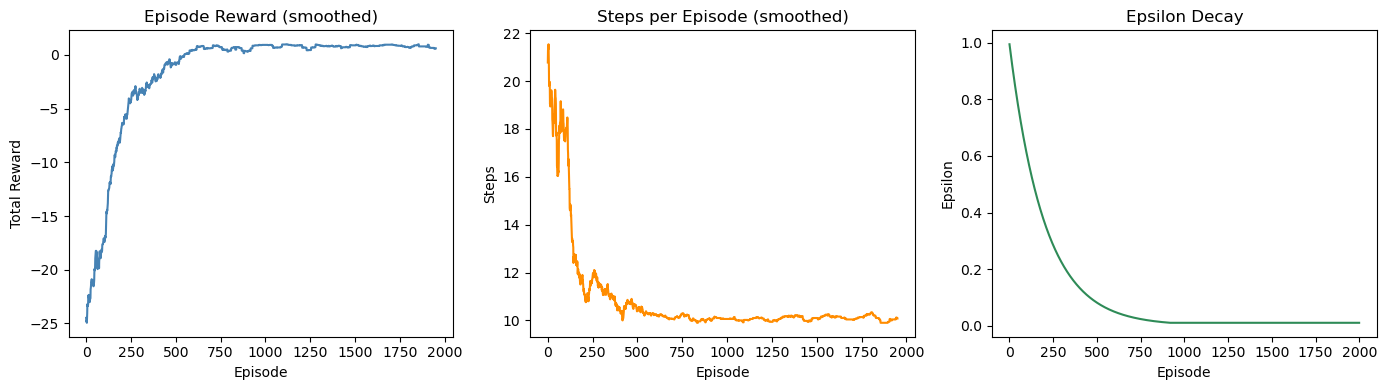

In [54]:
def smooth(x, window=50):
    return np.convolve(x, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(smooth(rewards), color='steelblue')
axes[0].set_title('Episode Reward (smoothed)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')

axes[1].plot(smooth(steps), color='darkorange')
axes[1].set_title('Steps per Episode (smoothed)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')

axes[2].plot(eps_hist, color='seagreen')
axes[2].set_title('Epsilon Decay')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Epsilon')

plt.tight_layout()
plt.show()

#### Greedy policy rollout

In [55]:
def greedy_rollout(env, agent, max_steps=50):
    s = env.reset()
    path = [env._decode(s)]
    total_reward = 0

    for _ in range(max_steps):
        a = int(np.argmax(agent.Q[s]))
        s_next, r, done = env.step(a)
        path.append(env._decode(s_next))
        total_reward += r
        s = s_next
        if done:
            break

    return path, total_reward


path, total_r = greedy_rollout(env, agent)
print(f"Path length: {len(path)} steps, Total reward: {total_r:.1f}")
print("Path:", path)

Path length: 11 steps, Total reward: 1.0
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (5, 3), (5, 4), (5, 5)]


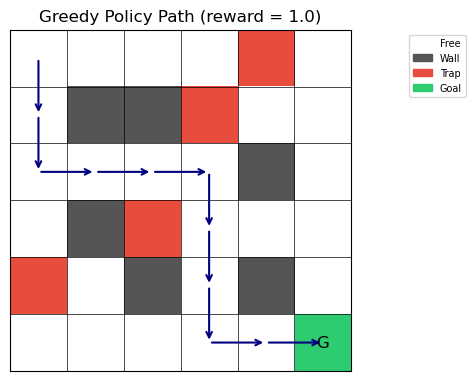

In [56]:
fig, ax = plt.subplots(figsize=(5, 5))
env.render(ax=ax)

# draw path
for i in range(len(path) - 1):
    r0, c0 = path[i]
    r1, c1 = path[i + 1]
    ax.annotate('', xy=(c1, r1), xytext=(c0, r0),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))

ax.set_title(f'Greedy Policy Path (reward = {total_r:.1f})')
plt.tight_layout()
plt.show()

#### Q-table visualisation

For each state, we will see the maximum Q-value (i.e., $\max_a Q(s, a)$) and the greedy action.

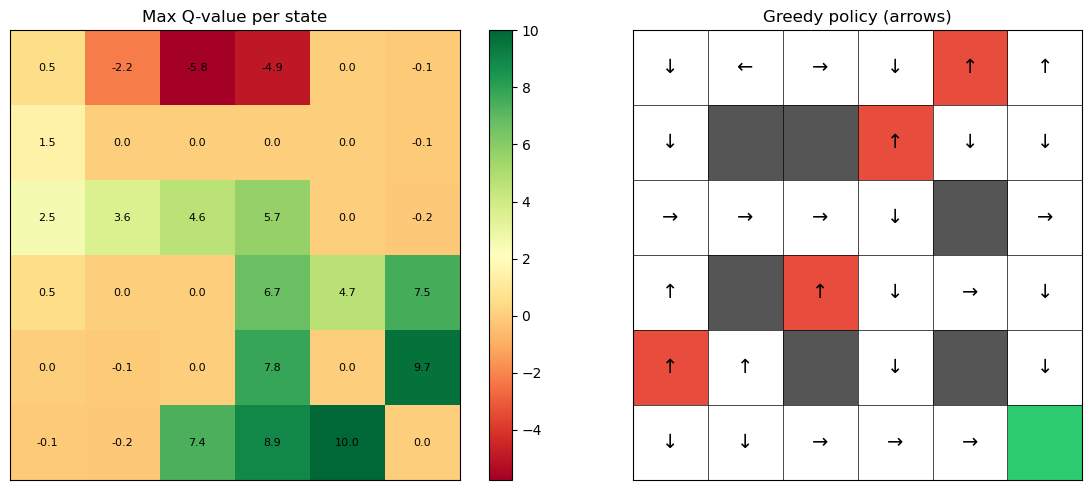

In [57]:
ACTION_ARROWS = {0: u'\u2191', 1: u'\u2193', 2: u'\u2190', 3: u'\u2192'}

N = env.N
max_q = np.max(agent.Q, axis=1).reshape(N, N)
best_a = np.argmax(agent.Q, axis=1).reshape(N, N)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# max Q-value heatmap
im = axes[0].imshow(max_q, cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Max Q-value per state')
axes[0].set_xticks([]); axes[0].set_yticks([])
for r in range(N):
    for c in range(N):
        axes[0].text(c, r, f'{max_q[r, c]:.1f}', ha='center', va='center', fontsize=8)

# greedy action arrows
axes[1].imshow(env.grid, cmap=ListedColormap(['white', '#555555', '#e74c3c', '#2ecc71']), vmin=0, vmax=3)
for x in range(N + 1):
    axes[1].axhline(x - 0.5, color='black', linewidth=0.5)
    axes[1].axvline(x - 0.5, color='black', linewidth=0.5)
axes[1].set_title('Greedy policy (arrows)')
axes[1].set_xticks([]); axes[1].set_yticks([])
for r in range(N):
    for c in range(N):
        if env.grid[r, c] in (1, 3):  # wall or goal
            continue
        arrow = ACTION_ARROWS[best_a[r, c]]
        axes[1].text(c, r, arrow, ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

#### Effect of hyperparameters

We run a small sweep over learning rate $\alpha$ and discount factor $\gamma$ to see how they affect convergence.

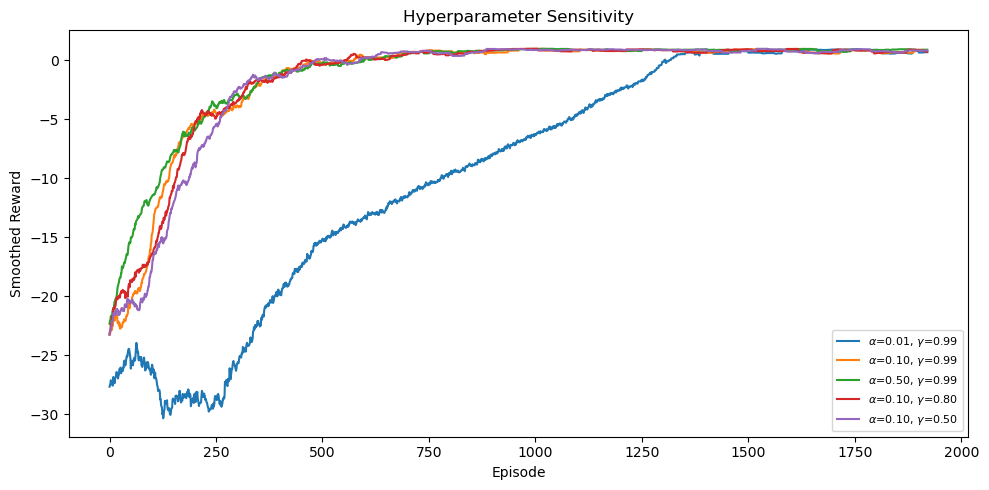

In [58]:
configs = [
    {'alpha': 0.01, 'gamma': 0.99, 'label': r'$\alpha$=0.01, $\gamma$=0.99'},
    {'alpha': 0.10, 'gamma': 0.99, 'label': r'$\alpha$=0.10, $\gamma$=0.99'},
    {'alpha': 0.50, 'gamma': 0.99, 'label': r'$\alpha$=0.50, $\gamma$=0.99'},
    {'alpha': 0.10, 'gamma': 0.80, 'label': r'$\alpha$=0.10, $\gamma$=0.80'},
    {'alpha': 0.10, 'gamma': 0.50, 'label': r'$\alpha$=0.10, $\gamma$=0.50'},
]

fig, ax = plt.subplots(figsize=(10, 5))

for cfg in configs:
    np.random.seed(0); random.seed(0)
    env_ = GridWorld(N=6, walls=WALLS, traps=TRAPS)
    ag_ = QLearningAgent(env_.n_states, env_.n_actions,
                         alpha=cfg['alpha'], gamma=cfg['gamma'])
    r_hist, _, _ = train(env_, ag_, n_episodes=2000)
    ax.plot(smooth(r_hist, 80), label=cfg['label'])

ax.set_xlabel('Episode')
ax.set_ylabel('Smoothed Reward')
ax.set_title('Hyperparameter Sensitivity')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Summary

**Why does Q-learning work for this grid-world problem?**

The state space is small ($6 \times 6 = 36$ states) and fully observable, so a tabular Q-function suffices. The TD update propagates reward signals backwards through visited states without needing an explicit model of $P$.

**Limitations of tabular Q-learning**  

- The Q-table has $|\mathcal{S}| \times |\mathcal{A}|$ entries. For large or continuous state spaces (e.g., pixel-based observations), this is intractable.  
- So, what can we do? We come to **Deep Q-Networks (DQN)**, where $Q(s, a; \theta)$ is approximated by a deep neural network. We will see this next.

**Notes.**
1. Q-learning is off-policy: the update target uses $\max_{a'}$ independently of the behaviour policy.  
2. $\varepsilon$-greedy balances *exploration* and *exploitation*; annealing $\varepsilon$ is important for convergence in practice.  
3. High $\gamma$ ($\approx 1$) values long-horizon returns; low $\gamma$ makes the agent myopic.  
4. Large $\alpha$ speeds up initial learning but can cause instability; small $\alpha$ is stable but slow.